# Embedding and Vector Storage

In this notebook, we generate vector embeddings for the chunked movie data and store them in a vector database (**ChromaDB**).

Each chunk (metadata, cast, and plot) is converted into a embedding using a pre-trained embedding model, `all-mpnet-base-v2`, from the Sentence Transformers library.

## Mount Google Drive

We mount Google Drive to access and store files, including the vector database. This enables us to save the embeddings for later use without needing to re-create them.

This is especially useful when working in Colab, where the runtime is temporary (which we ran into multiple times). Persisting the vector store to Drive ensures it can be re-used across sessions.

**References:**
- https://colab.research.google.com/notebooks/io.ipynb
- https://cookbook.chromadb.dev/core/clients/#persistent-client

In [ ]:
# Mount Google Drive to access and save files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Chunked Data

We load the previously generated chunked dataset, which contains metadata, cast, and plot text prepared for embedding.

In [ ]:
# Load chunked dataset
import pandas as pd
df = pd.read_csv("movie_rag_chunks.csv", encoding="utf-8")
df.head()

,wiki_movie_id,movie_name,chunk_type,chunk_id,chunk_text
0,23890098,Taxi Blues,metadata,23890098_meta_0,Movie Title: Taxi Blues\nWiki ID: 23890098\nRe...
1,23890098,Taxi Blues,cast,23890098_cast_0,Movie Title: Taxi Blues\nWiki ID: 23890098\nRe...
2,23890098,Taxi Blues,plot,23890098_plot_0,Movie Title: Taxi Blues\nWiki ID: 23890098\nRe...
3,31186339,The Hunger Games,metadata,31186339_meta_0,Movie Title: The Hunger Games\nWiki ID: 311863...
4,31186339,The Hunger Games,cast,31186339_cast_0,Movie Title: The Hunger Games\nWiki ID: 311863...


## Initialize Embedding Model

We load a pre-trained Sentence Transformers model, `all-mpnet-base-v2`, to generate embeddings for each text chunk.

This model is designed to produce high-quality semantic embeddings, making it useful for sematic search.

**Documentation:**
- https://www.sbert.net/docs/sentence_transformer/pretrained_models.html
- https://huggingface.co/sentence-transformers/all-mpnet-base-v2

In [ ]:
# Import sentence transformers
from sentence_transformers import SentenceTransformer

# Load pretrained model
model = SentenceTransformer("all-mpnet-base-v2")

## Generate Embeddings for Chunks

We extract the chunks from the dataframe and use the embedding model to convert each chunk into a dense vector representation. Batch processing is used to make embedding generation more efficient.

In [ ]:
# Extract "documents" from dataframe
documents = df['chunk_text'].to_list()

# Encode all dcouments
embeddings = model.encode(documents, batch_size=32, show_progress_bar=True)

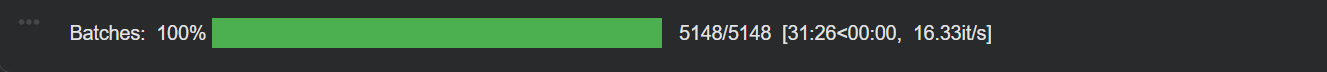

### Save Embeddings
We save the generated embeddings as a NumPy file for later use. This allows us to reload the embeddings without recomputing them.

In [ ]:
# Save embeddings
import numpy as np
np.save("/content/drive/MyDrive/embeddings.npy", embeddings)

## Prepare Data for the Vector Store
Before inserting the chunks into ChromaDB, we reformat the data to match the structure expected by the vector store.

We rename the text and identifier columns so they align with the fields we want to use in the database. We also convert selected metadata columns into a list of dictionaries, where each dictionary represents the metadata associated with one chunk. This is done by specifying `orient="records"`.

Example:

```
[
  {'wiki_movie_id': 31186339, 'movie_name': 'The Hunger Games', 'chunk_type': 'plot'},
  {'wiki_movie_id': 23524192, 'movie_name': 'The Karate Kid', 'chunk_type': 'cast'},
  {'wiki_movie_id': 13239722, 'movie_name': 'Sex and the City: The Movie', 'chunk_type': 'metadata'},
  {'wiki_movie_id': 3701905, 'movie_name': 'The Polar Express', 'chunk_type': 'plot'},
  ...
]
```

This ensures that every document, embedding, ID, and metadata record remains aligned when added to the vector store.

**References:**
- https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_dict.html
- https://www.geeksforgeeks.org/python/pandas-dataframe-to_dict/

In [ ]:
# Prepare dataframe for vector store

# Rename columns
chroma_df = df.rename(columns={
    "chunk_id": "id",
    "chunk_text": "document"
})

# Convert metadata fields to a dictionary
metadatas = chroma_df[["wiki_movie_id", "movie_name", "chunk_type"]].to_dict(orient="records")

# Convert ids to list
ids = chroma_df["id"].to_list()

We load the previously saved embeddings from file to prepare them for insertion into the vector database.

In [ ]:
import numpy as np

# Load embeddings
embeddings = np.load("embeddings.npy")
print(type(embeddings))

<class 'numpy.ndarray'>


We extract the document text from the dataframe to prepare it for insertion into the vector database.

In [ ]:
# Get documents
docs = chroma_df['document'].to_list()

### Validate Data Alignment

Before inserting data into the vector store, we verify that all components (documents, embeddings, IDs, and metadata) have the same length. This ensures that each embedding correctly corresponds to its associated document and metadata.

In [ ]:
# Ensure that all records are the same length
for i in [docs, embeddings, ids, metadatas]:
  print(len(i))

164714
164714
164714
164714


## Add data into Chromadb

In [ ]:
# Install chroma db
!pip install chromadb

### Initialize ChromaDB Client

We initialize a ChromaDB client with a persistent storage path in Google Drive. This allows the vector database to be saved and reused across sessions.

Using a persistent client ensures that the stored embeddings, documents, and metadata remain available without needing to rebuild the database each time.

**Documentation:** https://cookbook.chromadb.dev/core/clients/#persistent-client

In [ ]:
# Import chroma db
import chromadb

# Set up client and set path to google drive
client = chromadb.PersistentClient(path="/content/drive/MyDrive/chroma_db")

We create a ChromaDB collection to store the movie chunk embeddings together with their corresponding documents, IDs, and metadata.

In [ ]:
# Create collection
collection = client.create_collection(name="movie_chunks")

### Add Data to the Vector Store in Batches

We add the chunk data to the ChromaDB collection in batches rather than all at once. This is important because the client has a maximum batch size (**around 5,461**), and if we had tried to insert all our data at one time (164,714 records) we likely would've ran into a error.

For each batch, we insert the chunk IDs, documents, metadata, and embeddings together so that all records remain aligned in the vector store. Progress is printed during the loop to monitor how much of the dataset has been added.

**Documentation:** https://docs.trychroma.com/reference/python/client#get_max_batch_size

In [ ]:
# Find the max batch size for batch processing
max_batch_size = client.get_max_batch_size() - 100

In [ ]:
# Move data to collection in batches
for i in range(0, len(ids), max_batch_size):
    collection.add(
        ids=ids[i:i + max_batch_size],
        documents=docs[i:i + max_batch_size],
        metadatas=metadatas[i:i + max_batch_size],
        embeddings=embeddings[i:i + max_batch_size]
    )
    print(f"Added {min(i + max_batch_size, len(ids))}/{len(ids)}")

Added 5361/164714
Added 10722/164714
Added 16083/164714
Added 21444/164714
Added 26805/164714
Added 32166/164714
Added 37527/164714
Added 42888/164714
Added 48249/164714
Added 53610/164714
Added 58971/164714
Added 64332/164714
Added 69693/164714
Added 75054/164714
Added 80415/164714
Added 85776/164714
Added 91137/164714
Added 96498/164714
Added 101859/164714
Added 107220/164714
Added 112581/164714
Added 117942/164714
Added 123303/164714
Added 128664/164714
Added 134025/164714
Added 139386/164714
Added 144747/164714
Added 150108/164714
Added 155469/164714
Added 160830/164714
Added 164714/164714


We verify that all chunks have been successfully inserted into the ChromaDB collection by checking the total number of stored entries.

In [ ]:
# Make sure all 164,714 entries were inserted
collection.count()

164714

# Summary

In this notebook, we generated embeddings for the chunked movie dataset and stored them in a persistent ChromaDB vector database. The resulting collection contains metadata, cast, and plot chunks represented as embeddings, allowing efficient semantic-search based retrieval.

This completes the embedding and indexing stage of our RAG pipeline.